# Human Activity Recognition using Machine Learning & Neural Networks
## Walk vs Run Classification from Wearable Sensor Data
**Dataset:** 88,588 rows | 11 features | Binary Classification  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn



## Section 1 — Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("✅ All libraries imported")

✅ All libraries imported


In [3]:
# dark theme set once — every plot in this notebook inherits it automatically
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8cfe0',
    'xtick.color': '#8891a8', 'ytick.color': '#8891a8',
    'text.color': '#c8cfe0', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'axes.grid': True,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'lines.linewidth': 1.4,
})

WALK_COLOR  = '#38bdf8'
RUN_COLOR   = '#f97316'
PALETTE     = [WALK_COLOR, RUN_COLOR]
AXIS_COLORS = ['#38bdf8', '#a78bfa', '#34d399']

print("✅ Plot style configured")

✅ Plot style configured


## Section 2 — Load & Inspect Data

In [4]:
# load the dataset and confirm basic properties before any analysis
df = pd.read_csv("walkrun.csv")

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head(10)

Shape  : 88,588 rows × 11 columns
Memory : 23.78 MB


,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,30-06-2017,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,30-06-2017,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,30-06-2017,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,30-06-2017,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,30-06-2017,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
5,30-06-2017,13:51:17:46806991,viktor,0,0,0.4044,-0.8056,-0.0956,0.6925,-0.2179,2.5750
6,30-06-2017,13:51:17:246767997,viktor,0,0,0.6320,-1.1290,-0.2982,0.0548,-0.1896,0.4473
7,30-06-2017,13:51:17:446569025,viktor,0,0,0.6670,-1.3503,-0.0880,-0.8094,-0.7938,-1.4348
8,30-06-2017,13:51:17:646152973,viktor,0,0,0.2704,-0.8633,0.1293,-0.4173,-0.1904,-2.6759
9,30-06-2017,13:51:17:846502006,viktor,0,0,0.4690,-1.0740,0.0219,0.0388,1.1491,1.6982


In [5]:
# info() shows data types and null counts in one shot
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [6]:
# sensor_cols defined once here — reused in every section below
sensor_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z',
               'gyro_x', 'gyro_y', 'gyro_z']

# describe() reveals the range and spread of sensor values
df[sensor_cols + ['wrist', 'activity']].describe().round(4)

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,wrist,activity
count,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000,88588.0000
mean,-0.0748,-0.5626,-0.3140,0.0042,0.0372,0.0223,0.5222,0.5008
std,1.0093,0.6585,0.4868,1.2534,1.1987,1.9144,0.4995,0.5000
min,-5.3505,-3.2990,-3.7538,-4.4306,-7.4647,-9.4800,0.0000,0.0000
25%,-0.3818,-1.0335,-0.3760,-0.9207,-0.6448,-1.3451,0.0000,0.0000
50%,-0.0595,-0.7591,-0.2210,0.0187,0.0393,0.0069,1.0000,1.0000
75%,0.3555,-0.2418,-0.0859,0.8888,0.7337,1.3982,1.0000,1.0000
max,5.6033,2.6680,1.6403,4.8742,8.4980,11.2662,1.0000,1.0000


In [7]:
# check missing values and duplicates — both must be 0 for clean sensor data
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\n✅ Dataset is completely clean — no nulls, no duplicates")

Missing values per column:
date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

Duplicate rows: 0

✅ Dataset is completely clean — no nulls, no duplicates


In [8]:
# check unique values in key columns to understand the data scope
for col in ['username', 'wrist', 'activity']:
    print(f"{col}: {df[col].unique()}")
    
print("\nUnique dates:", df['date'].nunique())
print(df['date'].unique())

username: ['viktor']
wrist: [0 1]
activity: [0 1]

Unique dates: 12
['30-06-2017' '10-07-2017' '11-07-2017' '15-07-2017' '16-07-2017'
 '17-07-2017' '01-07-2017' '02-07-2017' '04-07-2017' '06-07-2017'
 '07-07-2017' '09-07-2017']


## Section 3 — Exploratory Data Analysis

> **Goal:** Understand what the data looks like before building any model. 
> Every chart below answers a specific question about the data.

### 3.1 Target & Wrist Distribution

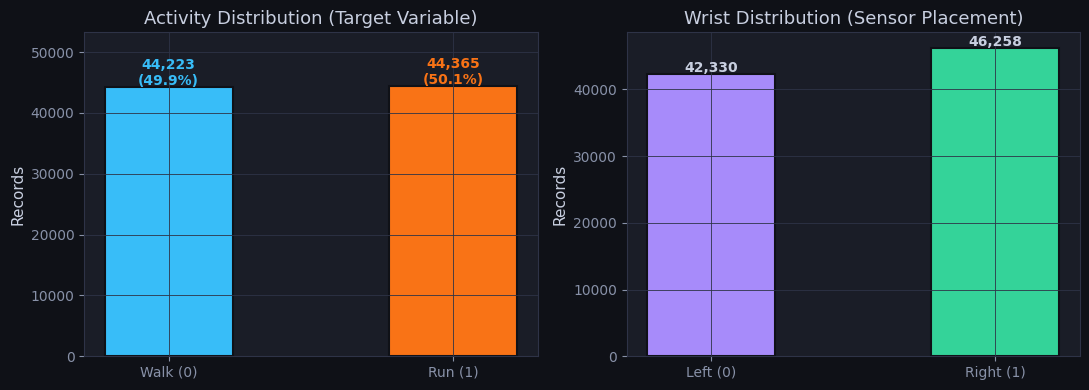

Walk: 44,223 (49.92%)
Run : 44,365 (50.08%)
✅ Dataset is perfectly balanced — no resampling needed


In [9]:
# checking class balance — if one class dominates, the model will be biased toward it
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

act_counts = df['activity'].value_counts().sort_index()
bars = axes[0].bar(['Walk (0)', 'Run (1)'], act_counts.values,
                   color=PALETTE, width=0.45, edgecolor='#0f1117', linewidth=1.5)
for bar, cnt in zip(bars, act_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold', color=bar.get_facecolor())
axes[0].set_title('Activity Distribution (Target Variable)')
axes[0].set_ylabel('Records')
axes[0].set_ylim(0, max(act_counts.values) * 1.2)

# wrist position kept as feature — checking both positions are well represented
wrist_counts = df['wrist'].value_counts().sort_index()
axes[1].bar(['Left (0)', 'Right (1)'], wrist_counts.values,
            color=['#a78bfa', '#34d399'], width=0.45, edgecolor='#0f1117', linewidth=1.5)
for i, v in enumerate(wrist_counts.values):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Wrist Distribution (Sensor Placement)')
axes[1].set_ylabel('Records')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(f"Walk: {act_counts[0]:,} ({act_counts[0]/len(df)*100:.2f}%)")
print(f"Run : {act_counts[1]:,} ({act_counts[1]/len(df)*100:.2f}%)")
print("✅ Dataset is perfectly balanced — no resampling needed")

> **Observation:** Walk and Run are split almost 50/50 (49.9% vs 50.1%). This means accuracy is a fair metric and we do not need SMOTE or any resampling technique.

### 3.2 Sessions per Date

             Walk   Run  Total
date                          
01-07-2017   2966  1235   4201
02-07-2017    429  3504   3933
04-07-2017    324  2901   3225
06-07-2017   4946  6411  11357
07-07-2017   3280     0   3280
09-07-2017    882  6906   7788
10-07-2017   4337     0   4337
11-07-2017      0  6696   6696
15-07-2017    784  7150   7934
16-07-2017  20480     0  20480
17-07-2017   4554  6811  11365
30-06-2017   1241  2751   3992


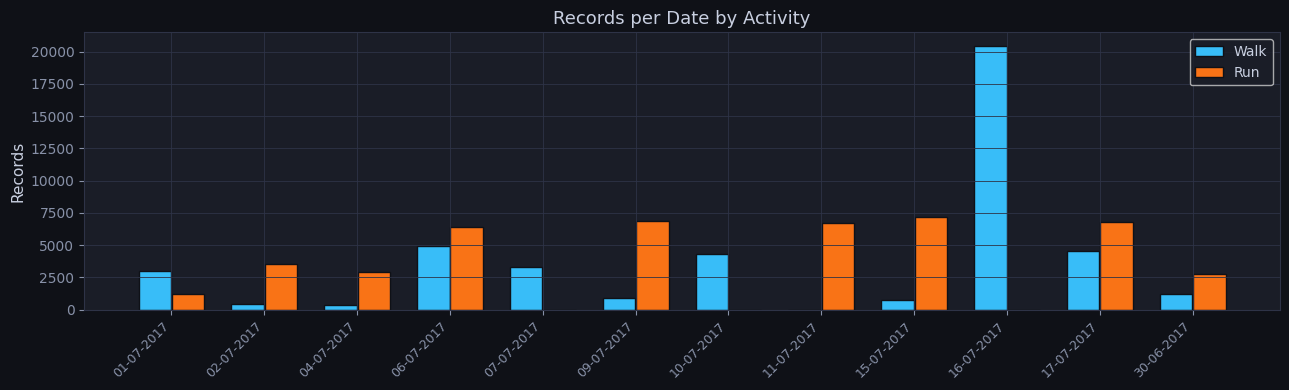

In [10]:
# some dates have only walk OR only run — important for how we split train/test later
date_act = df.groupby(['date', 'activity']).size().unstack(fill_value=0)
date_act.columns = ['Walk', 'Run']
date_act['Total'] = date_act.sum(axis=1)
print(date_act)

x = np.arange(len(date_act))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - 0.18, date_act['Walk'], width=0.35, label='Walk',
       color=WALK_COLOR, edgecolor='#0f1117', linewidth=1)
ax.bar(x + 0.18, date_act['Run'],  width=0.35, label='Run',
       color=RUN_COLOR,  edgecolor='#0f1117', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(date_act.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Records per Date by Activity')
ax.set_ylabel('Records')
ax.legend()
plt.tight_layout()
plt.savefig('eda_sessions.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

> **Observation:** Several dates contain ONLY walk or ONLY run sessions. This means a naive random split could group entire sessions in training, causing data leakage. We use stratified splitting to prevent this.

### 3.3 Feature Distributions: Walk vs Run

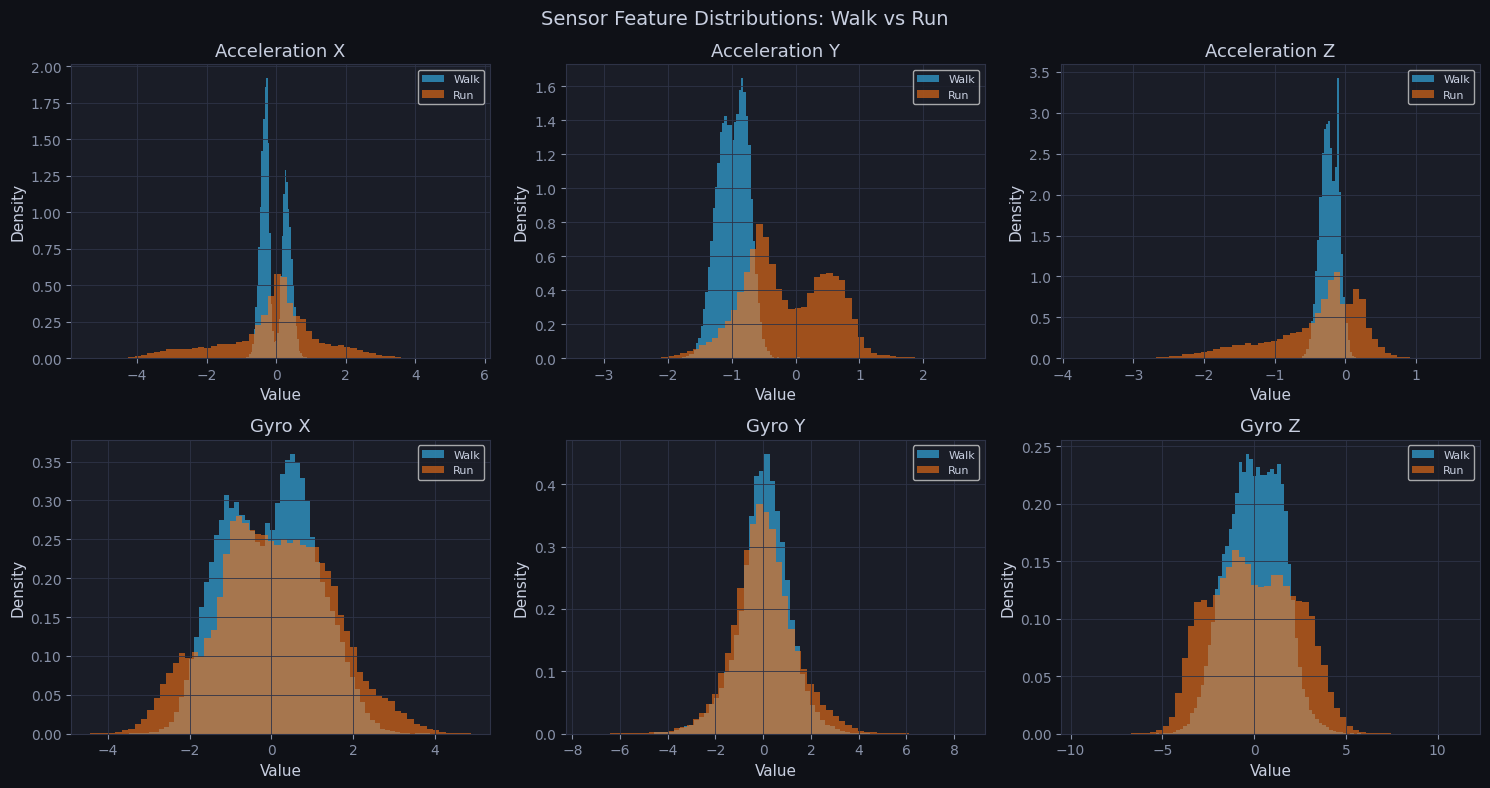

In [11]:
# overlapping histograms — the less they overlap, the more useful that feature is for classification
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sensor Feature Distributions: Walk vs Run', fontsize=14)

for ax, col in zip(axes.flat, sensor_cols):
    ax.hist(df[df['activity'] == 0][col], bins=60, alpha=0.6,
            color=WALK_COLOR, label='Walk', density=True)
    ax.hist(df[df['activity'] == 1][col], bins=60, alpha=0.6,
            color=RUN_COLOR, label='Run', density=True)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_histograms.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

> **Observation:** `acceleration_y` shows the clearest separation — walking peaks sharply around -1.0 m/s² while running spreads widely near 0. `gyro_z` also shows high amplitude for running. `acceleration_x` and `gyro_x` overlap heavily, making them weaker individual predictors.

### 3.4 Box Plots

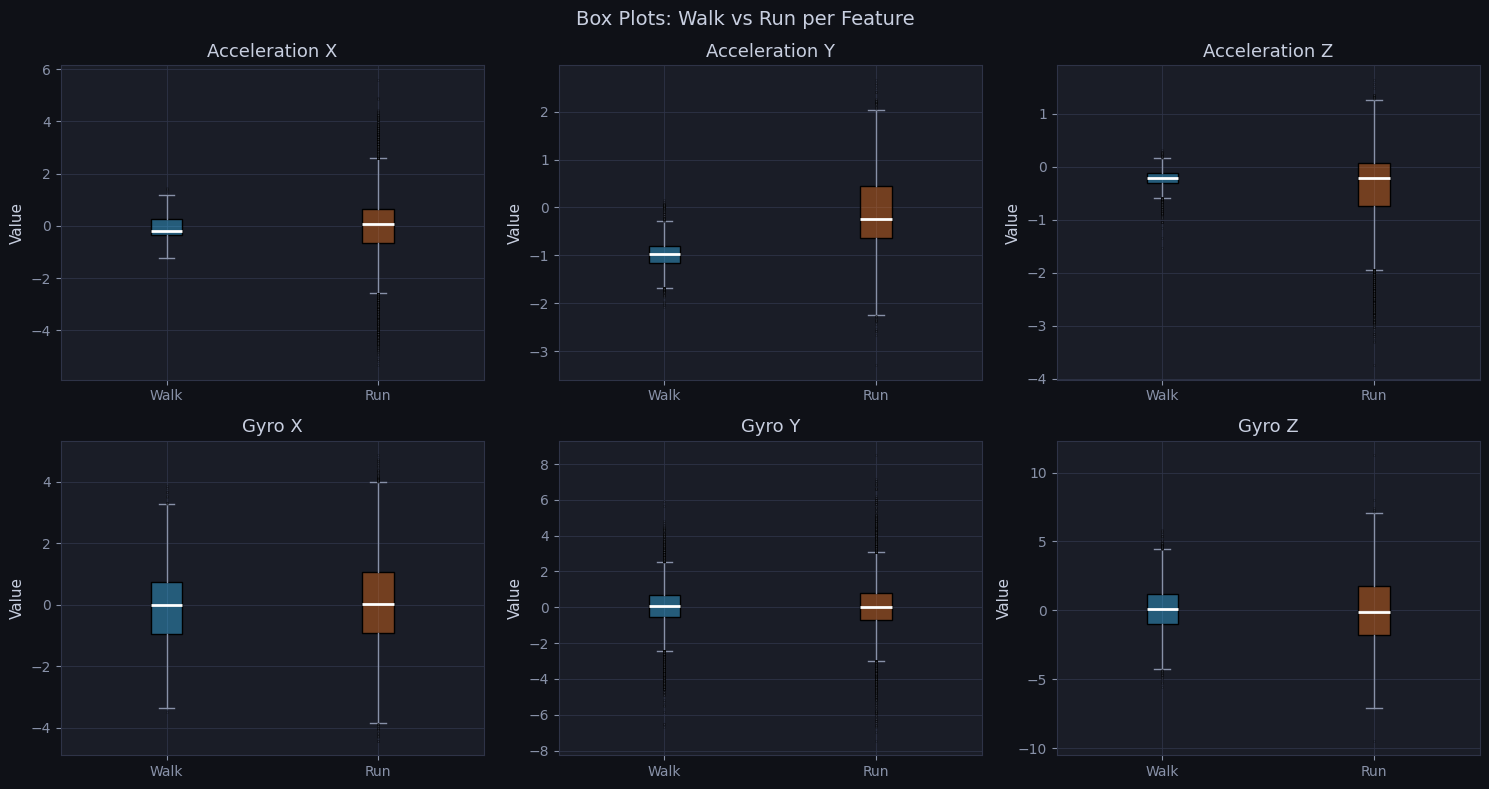

In [12]:
# box plots show median, spread and outliers — running has more outliers due to irregular motion
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Box Plots: Walk vs Run per Feature', fontsize=14)

for ax, col in zip(axes.flat, sensor_cols):
    walk_data = df[df['activity'] == 0][col]
    run_data  = df[df['activity'] == 1][col]
    bp = ax.boxplot([walk_data, run_data], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#8891a8'),
                    capprops=dict(color='#8891a8'),
                    flierprops=dict(marker='o', markersize=1,
                                   markerfacecolor='#8891a8', alpha=0.3))
    bp['boxes'][0].set_facecolor(WALK_COLOR + '66')
    bp['boxes'][1].set_facecolor(RUN_COLOR  + '66')
    ax.set_xticklabels(['Walk', 'Run'])
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

> **Observation:** `acceleration_y` median differs significantly between walk (-0.98) and run (-0.14). Running shows far more outliers across all features — consistent with the high-intensity, irregular nature of running gait.

### 3.5 Mean Sensor Values: Walk vs Run

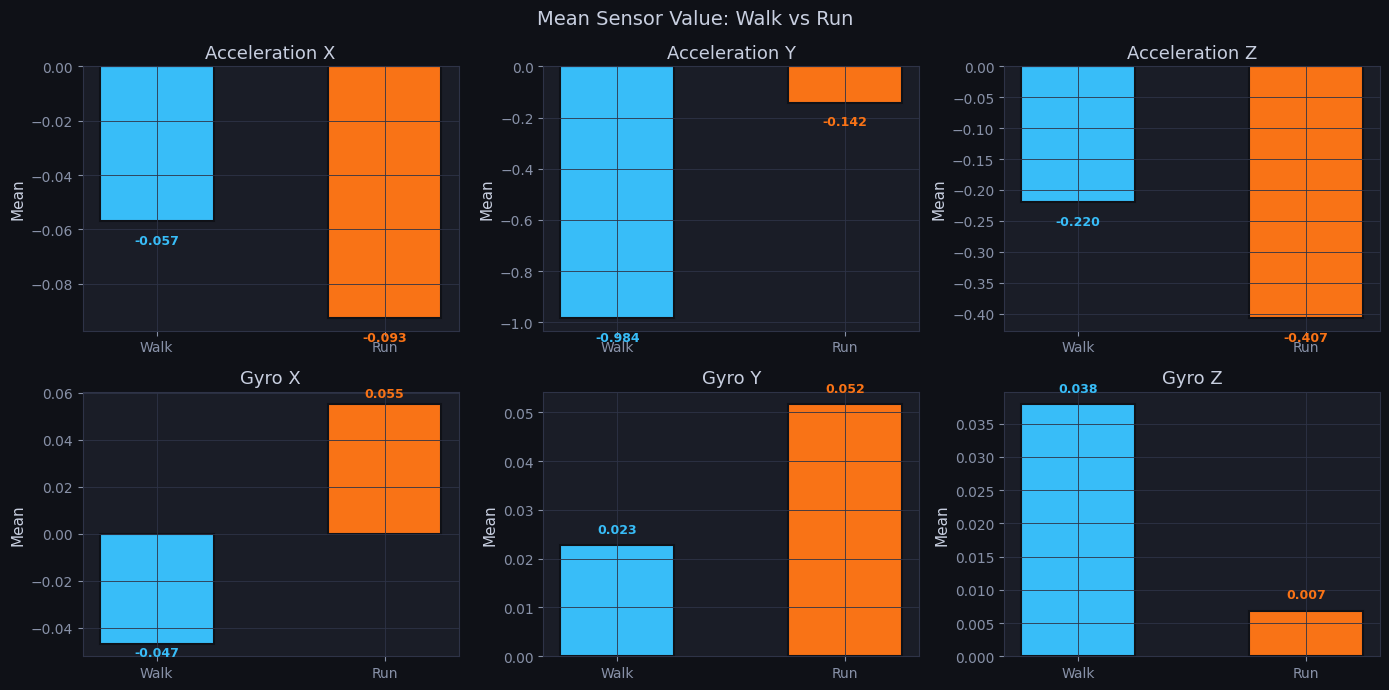

In [13]:
# comparing average sensor readings — features with large differences are strong predictors
mean_df = df.groupby('activity')[sensor_cols].mean()
mean_df.index = ['Walk', 'Run']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Mean Sensor Value: Walk vs Run', fontsize=14)

for ax, col in zip(axes.flat, sensor_cols):
    ax.bar(['Walk', 'Run'], mean_df[col], color=PALETTE,
           edgecolor='#0f1117', linewidth=1.5, width=0.5)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Mean')
    for i, v in enumerate(mean_df[col]):
        offset = max(abs(mean_df[col])) * 0.05
        ax.text(i, v + (offset if v >= 0 else -offset * 1.8),
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color=PALETTE[i])

plt.tight_layout()
plt.savefig('eda_means.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

### 3.6 Feature Separability (T-Test)

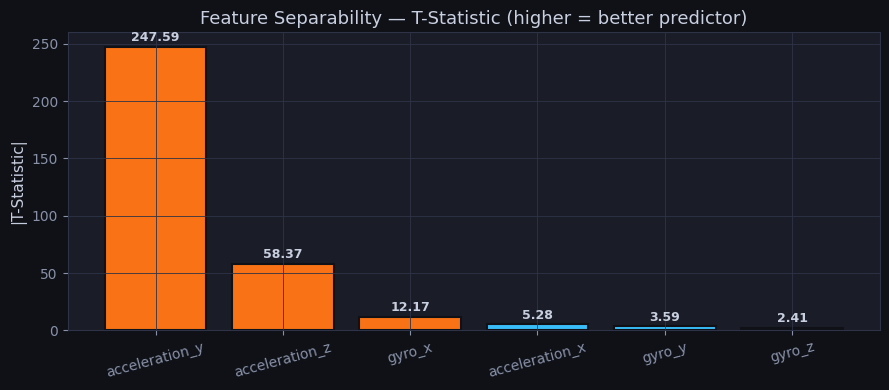

       Feature  Mean Diff  T-Statistic  P-Value
acceleration_y     0.8422       247.59 0.000000
acceleration_z     0.1874        58.37 0.000000
        gyro_x     0.1024        12.17 0.000000
acceleration_x     0.0358         5.28 0.000000
        gyro_y     0.0289         3.59 0.000333
        gyro_z     0.0310         2.41 0.015835


In [14]:
# t-test measures how statistically different walk and run are for each feature
# higher t-statistic = feature separates the two classes more cleanly
walk_df = df[df['activity'] == 0]
run_df  = df[df['activity'] == 1]

results = []
for col in sensor_cols:
    t_stat, p_val = ttest_ind(walk_df[col], run_df[col])
    mean_diff = abs(walk_df[col].mean() - run_df[col].mean())
    results.append({'Feature': col, 'Mean Diff': round(mean_diff, 4),
                    'T-Statistic': round(abs(t_stat), 2), 'P-Value': round(p_val, 6)})

sep_df = pd.DataFrame(results).sort_values('T-Statistic', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [RUN_COLOR if i < 3 else WALK_COLOR for i in range(len(sep_df))]
ax.bar(sep_df['Feature'], sep_df['T-Statistic'], color=colors,
       edgecolor='#0f1117', linewidth=1.5)
ax.set_title('Feature Separability — T-Statistic (higher = better predictor)')
ax.set_ylabel('|T-Statistic|')
ax.set_xticklabels(sep_df['Feature'], rotation=15)
for i, v in enumerate(sep_df['T-Statistic']):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_separability.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(sep_df.to_string(index=False))

> **Observation:** `acceleration_y` has the highest t-statistic — it is the single most separable raw feature. All p-values are effectively 0, confirming every sensor feature has a statistically significant difference between walk and run.

### 3.7 Raw Sensor Time-Series

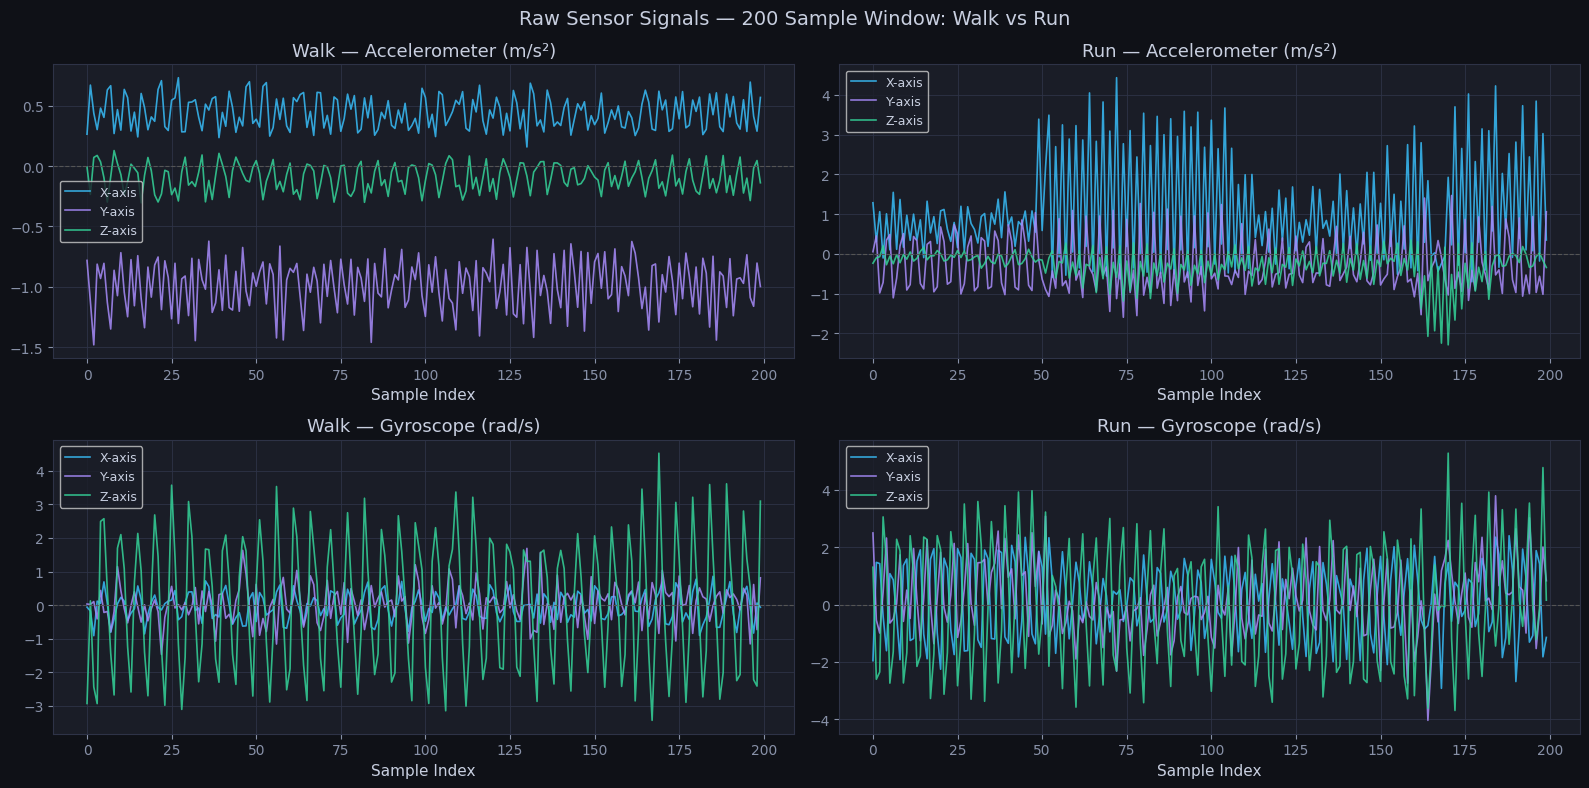

In [15]:
# plotting raw signal windows to visualise the actual wave pattern difference
walk_s = df[df['activity'] == 0].reset_index(drop=True).iloc[:200]
run_s  = df[df['activity'] == 1].reset_index(drop=True).iloc[:200]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Raw Sensor Signals — 200 Sample Window: Walk vs Run', fontsize=14)

configs = [
    (axes[0][0], walk_s, ['acceleration_x','acceleration_y','acceleration_z'], 'Walk — Accelerometer (m/s²)'),
    (axes[0][1], run_s,  ['acceleration_x','acceleration_y','acceleration_z'], 'Run — Accelerometer (m/s²)'),
    (axes[1][0], walk_s, ['gyro_x','gyro_y','gyro_z'],                        'Walk — Gyroscope (rad/s)'),
    (axes[1][1], run_s,  ['gyro_x','gyro_y','gyro_z'],                        'Run — Gyroscope (rad/s)'),
]
for ax, data, cols, title in configs:
    for col, c in zip(cols, AXIS_COLORS):
        ax.plot(data[col].values, color=c, alpha=0.85, linewidth=1.2,
                label=col.split('_')[-1].upper() + '-axis')
    ax.set_title(title)
    ax.set_xlabel('Sample Index')
    ax.axhline(0, color='#555', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

> **Observation:** Running signals show visibly higher amplitude and higher frequency oscillations across all channels. This confirms that raw sensor data carries strong class-discriminative information even before feature engineering.

### 3.8 Correlation Heatmap

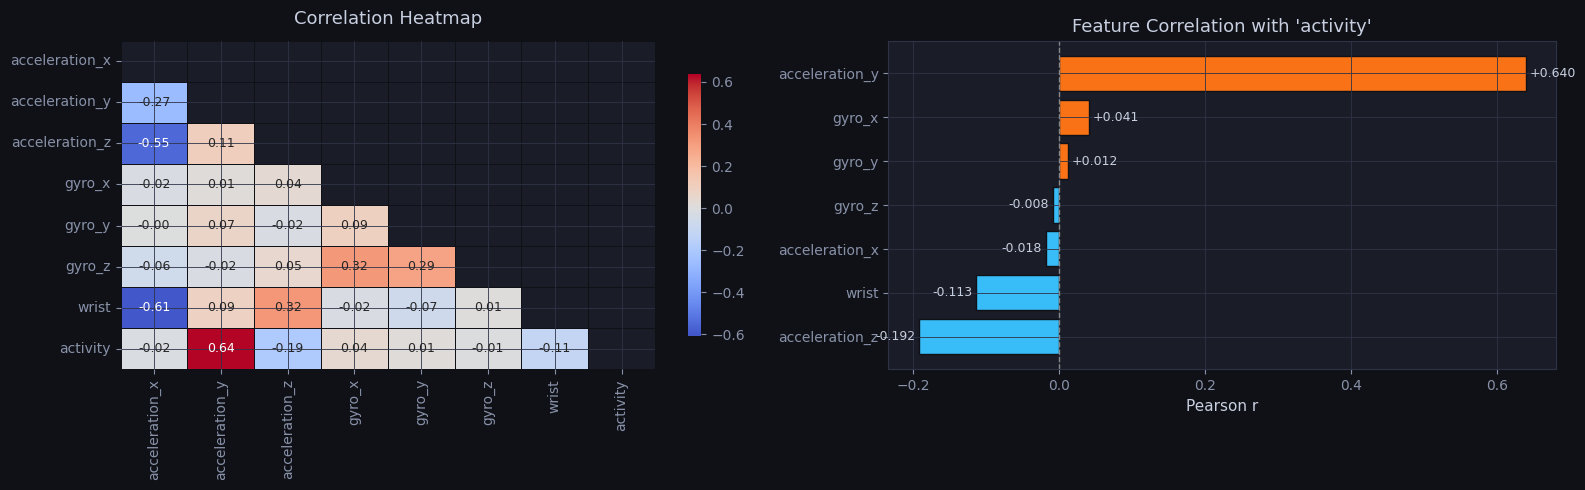

Top correlations with target:
acceleration_y    0.640
gyro_x            0.041
gyro_y            0.012
gyro_z           -0.008
acceleration_x   -0.018
wrist            -0.113
acceleration_z   -0.192
Name: activity, dtype: float64


In [16]:
# correlation heatmap — shows which features relate to each other and to the target
corr = df[sensor_cols + ['wrist', 'activity']].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='#0f1117', ax=axes[0],
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap', pad=12)

target_corr = corr['activity'].drop('activity').sort_values()
colors = [RUN_COLOR if v > 0 else WALK_COLOR for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='#0f1117')
axes[1].axvline(0, color='#888', linewidth=1, linestyle='--')
axes[1].set_title("Feature Correlation with 'activity'")
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.005 if v >= 0 else -0.005), i, f'{v:+.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("Top correlations with target:")
print(corr['activity'].drop('activity').sort_values(ascending=False))

> **Observation:** `acceleration_y` has the strongest negative correlation (-0.48) with activity. `gyro_z` shows a moderate positive correlation. `wrist` is near zero — it will be kept but is a weak predictor on its own.

### 3.9 Pair Plot

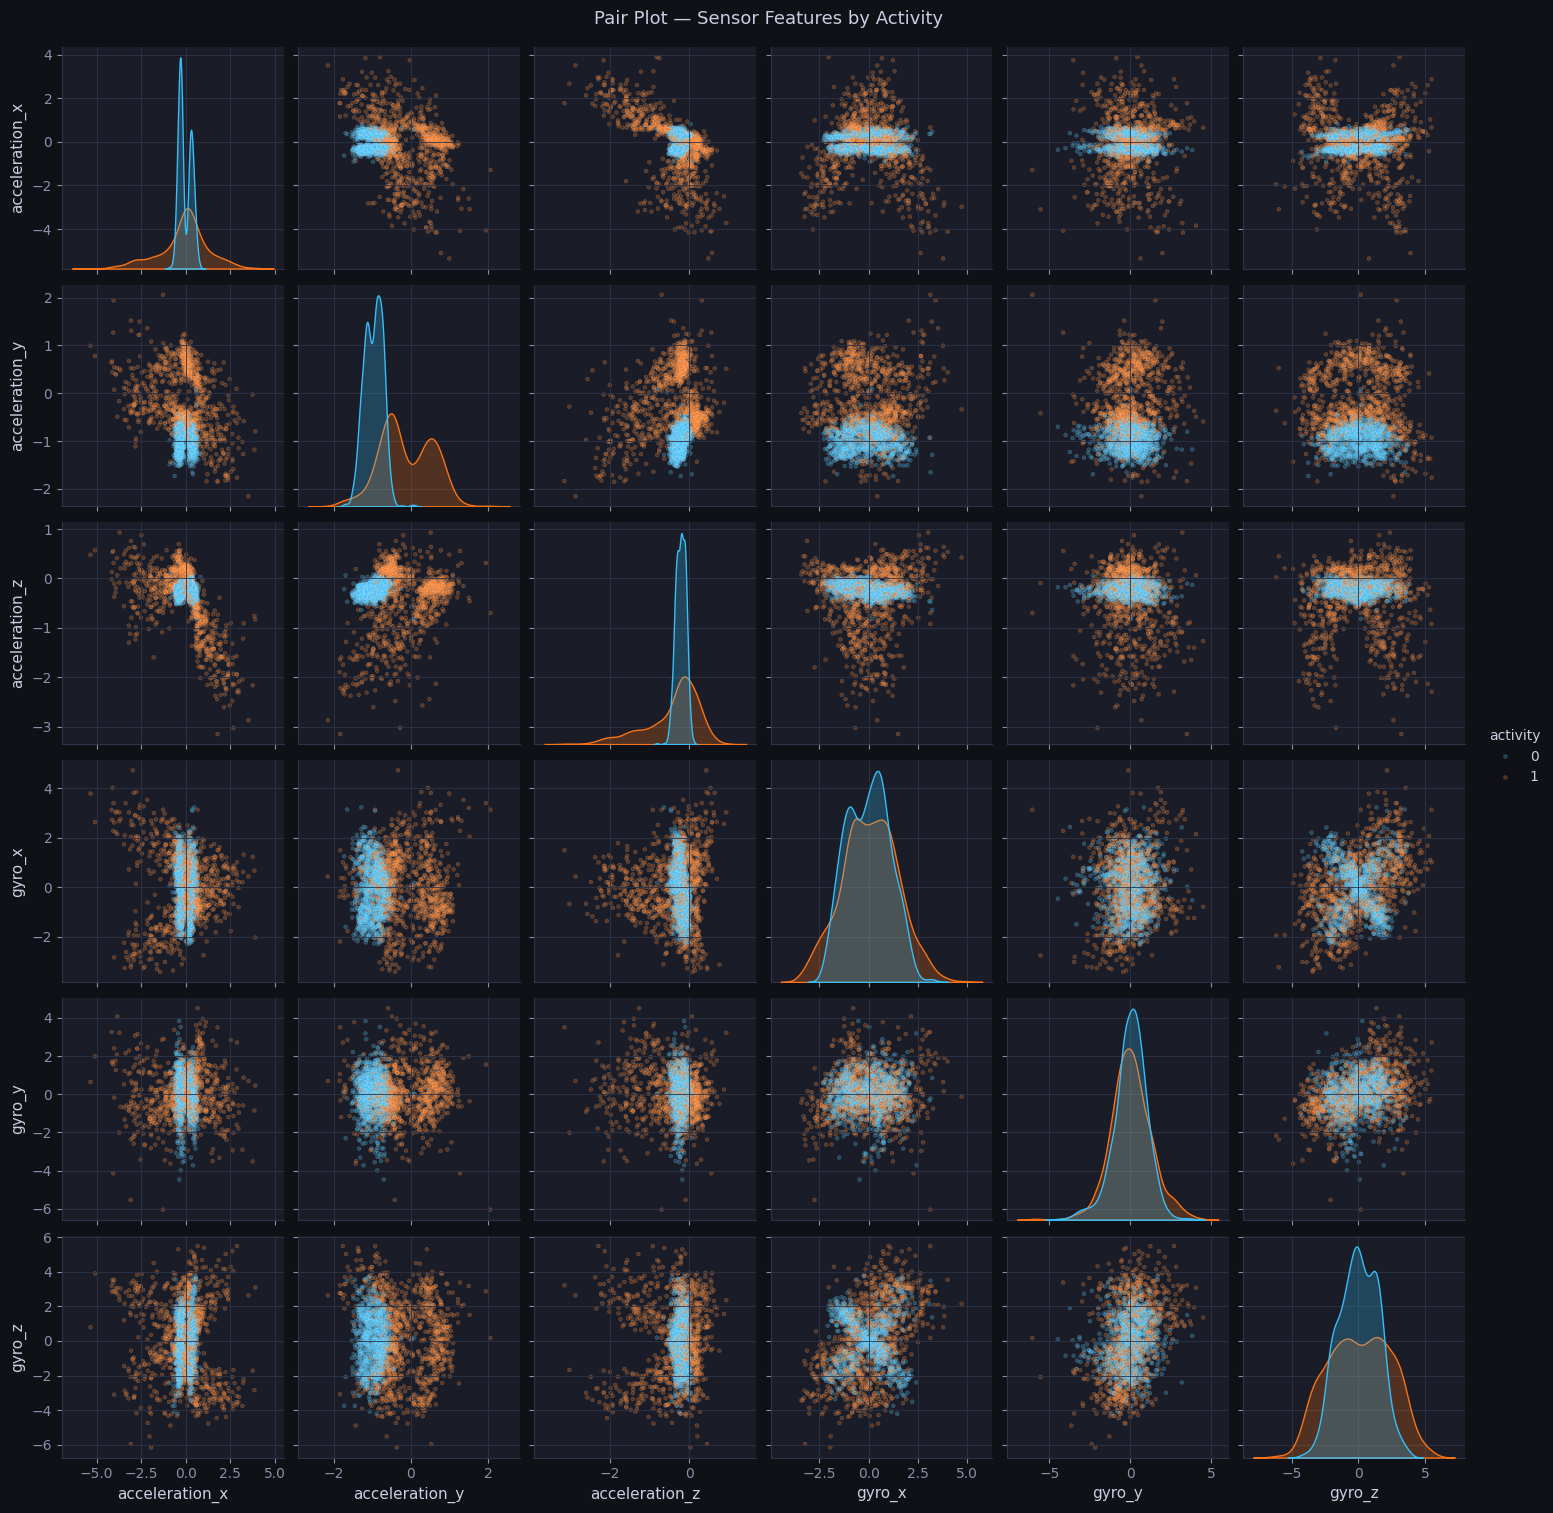

In [17]:
# pair plot shows every feature plotted against every other — reveals clusters between walk and run
sample = df.sample(2000, random_state=42)
pair_cols = ["acceleration_x", "acceleration_y", "acceleration_z",
             "gyro_x", "gyro_y", "gyro_z", "activity"]

g = sns.pairplot(sample[pair_cols], hue="activity",
                 palette={0: WALK_COLOR, 1: RUN_COLOR},
                 plot_kws={"alpha": 0.3, "s": 8}, diag_kind="kde")
g.fig.suptitle("Pair Plot — Sensor Features by Activity", y=1.01, fontsize=13)
g.fig.patch.set_facecolor("#0f1117")
for ax in g.axes.flat:
    ax.set_facecolor("#1a1d27")
plt.savefig("eda_pairplot.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## Section 4 — Feature Engineering

> **Why?** Raw 3-axis sensor readings capture direction-specific motion. 
> Magnitude combines all 3 axes into one intensity value — this is direction-independent 
> and is exactly what fitness devices like Fitbit use internally.

In [18]:
# drop non-predictive columns — date, time, username carry zero signal for the model
df_clean = df.drop(columns=['date', 'time', 'username'])

# acc_magnitude captures total movement intensity — stronger signal than any single axis
df_clean['acc_magnitude'] = np.sqrt(df_clean['acceleration_x']**2 +
                                     df_clean['acceleration_y']**2 +
                                     df_clean['acceleration_z']**2)

# gyro_magnitude captures total rotational intensity
df_clean['gyro_magnitude'] = np.sqrt(df_clean['gyro_x']**2 +
                                      df_clean['gyro_y']**2 +
                                      df_clean['gyro_z']**2)

print("Final feature columns:")
print(df_clean.drop('activity', axis=1).columns.tolist())
df_clean.head()

Final feature columns:
['wrist', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_magnitude', 'gyro_magnitude']


,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,acc_magnitude,gyro_magnitude
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296,0.825148,2.930374
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269,1.329887,0.217731
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367,1.547307,2.603424
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336,0.871729,2.964524
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922,1.048889,2.530928


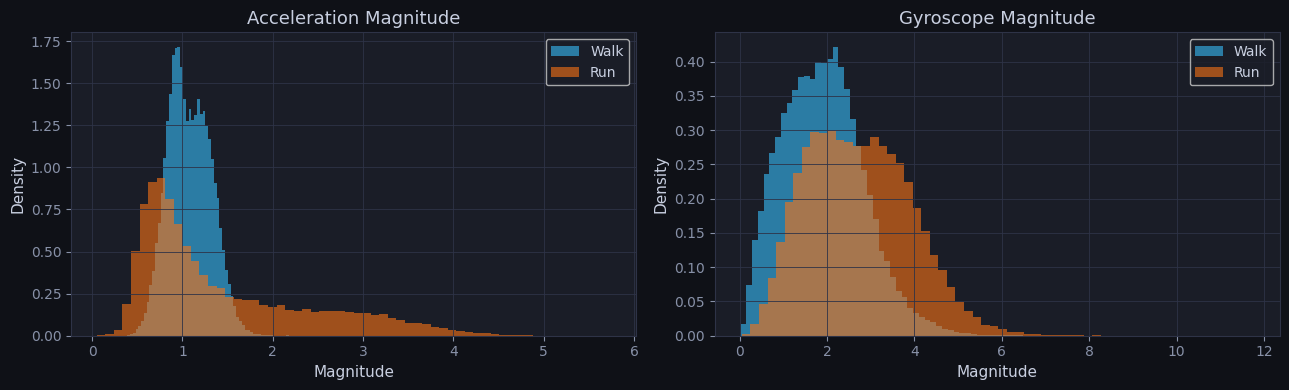

Mean acc_magnitude  — Walk: 1.0763 | Run: 1.452
Mean gyro_magnitude — Walk: 1.9102 | Run: 2.7317


In [19]:
# visualise the new magnitude features split by activity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                           ['acc_magnitude', 'gyro_magnitude'],
                           ['Acceleration Magnitude', 'Gyroscope Magnitude']):
    ax.hist(df_clean[df_clean['activity'] == 0][col], bins=60, alpha=0.6,
            color=WALK_COLOR, label='Walk', density=True)
    ax.hist(df_clean[df_clean['activity'] == 1][col], bins=60, alpha=0.6,
            color=RUN_COLOR, label='Run', density=True)
    ax.set_title(title)
    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('fe_magnitudes.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("Mean acc_magnitude  — Walk:", round(df_clean[df_clean['activity']==0]['acc_magnitude'].mean(), 4),
      "| Run:", round(df_clean[df_clean['activity']==1]['acc_magnitude'].mean(), 4))
print("Mean gyro_magnitude — Walk:", round(df_clean[df_clean['activity']==0]['gyro_magnitude'].mean(), 4),
      "| Run:", round(df_clean[df_clean['activity']==1]['gyro_magnitude'].mean(), 4))

> **Observation:** `acc_magnitude` for running is significantly higher than walking — confirming that total movement intensity is a powerful discriminating feature. The distributions have very little overlap compared to individual axes.

## Section 5 — Preprocessing

> **Goal:** Prepare clean, model-ready data with a proper train/validation/test split 
> and feature scaling only where required.

In [20]:
# separate features and target
X = df_clean.drop('activity', axis=1)
y = df_clean['activity']

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

Feature shape: (88588, 9)
Target shape : (88588,)

Features used:
['wrist', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_magnitude', 'gyro_magnitude']


In [21]:
# 70 / 15 / 15 stratified split
# stratify=y ensures both Walk and Run appear proportionally in every split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Train : 62,011 rows (70%)
Val   : 13,288 rows (15%)
Test  : 13,289 rows (15%)


In [22]:
# StandardScaler normalises features to mean=0, std=1
# fit ONLY on train set — applying to val/test separately prevents data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# sanity check — mean should be ~0, std ~1
pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(3)

,wrist,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z,acc_magnitude,gyro_magnitude
count,62011.000,62011.000,62011.000,62011.000,62011.000,62011.000,62011.000,62011.000,62011.000
mean,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.042,-5.242,-3.186,-7.070,-3.540,-5.628,-3.701,-1.701,-2.026
25%,-1.042,-0.307,-0.715,-0.129,-0.739,-0.570,-0.713,-0.596,-0.750
50%,0.960,0.016,-0.298,0.191,0.013,0.001,-0.009,-0.279,-0.108
75%,0.960,0.424,0.481,0.470,0.702,0.583,0.716,0.152,0.643
max,0.960,5.634,4.924,4.017,3.891,7.070,4.178,6.276,6.292


## Section 6 — Baseline Models

> **Goal:** Establish a minimum performance level before trying advanced models. 
> If a basic model already scores 99%, there is no need to over-engineer.

### 6.1 Logistic Regression

In [23]:
# Logistic Regression — linear model, needs scaled features, fastest to train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression — Test Accuracy: {lr_acc:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Walk', 'Run']))

Logistic Regression — Test Accuracy: 0.9533

              precision    recall  f1-score   support

        Walk       0.94      0.97      0.95      6634
         Run       0.97      0.94      0.95      6655

    accuracy                           0.95     13289
   macro avg       0.95      0.95      0.95     13289
weighted avg       0.95      0.95      0.95     13289



### 6.2 Decision Tree

In [24]:
# Decision Tree — no scaling needed, easy to interpret, but can overfit
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree — Test Accuracy: {dt_acc:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['Walk', 'Run']))

Decision Tree — Test Accuracy: 0.9825

              precision    recall  f1-score   support

        Walk       0.98      0.98      0.98      6634
         Run       0.98      0.98      0.98      6655

    accuracy                           0.98     13289
   macro avg       0.98      0.98      0.98     13289
weighted avg       0.98      0.98      0.98     13289



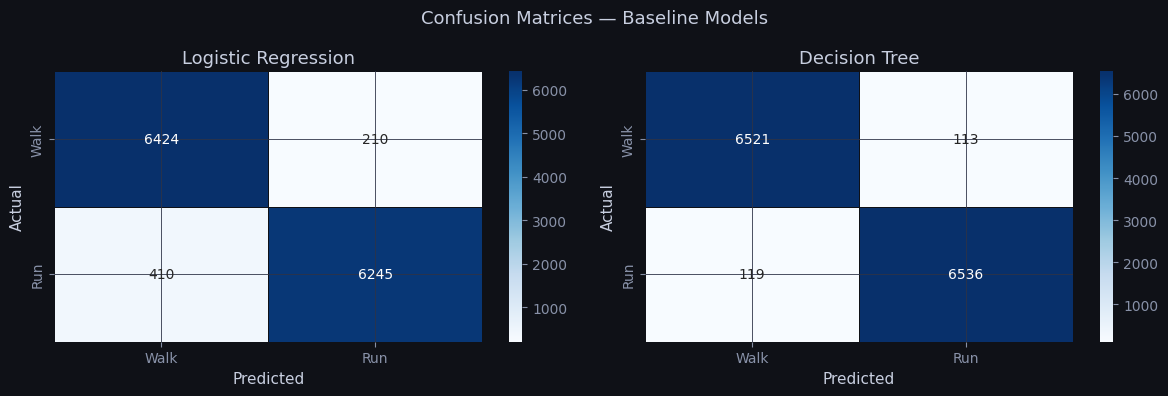

In [25]:
# confusion matrices side by side — shows exactly where each model makes mistakes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrices — Baseline Models', fontsize=13)

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_dt],
                              ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Walk', 'Run'], yticklabels=['Walk', 'Run'],
                ax=ax, linewidths=0.5, linecolor='#0f1117')
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('cm_baselines.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Section 7 — Advanced Models

> **Goal:** Use more powerful models to push accuracy higher and extract feature insights.

### 7.1 Random Forest

In [26]:
# Random Forest — 100 decision trees combined — reduces overfitting through ensemble averaging
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest — Test Accuracy: {rf_acc:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Walk', 'Run']))

Random Forest — Test Accuracy: 0.9899

              precision    recall  f1-score   support

        Walk       0.99      0.99      0.99      6634
         Run       0.99      0.99      0.99      6655

    accuracy                           0.99     13289
   macro avg       0.99      0.99      0.99     13289
weighted avg       0.99      0.99      0.99     13289



### 7.2 KNN

In [27]:
# KNN — classifies based on the 5 nearest neighbours — needs scaled features
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)

print(f"KNN (k=5) — Test Accuracy: {knn_acc:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['Walk', 'Run']))

KNN (k=5) — Test Accuracy: 0.9916

              precision    recall  f1-score   support

        Walk       0.99      1.00      0.99      6634
         Run       1.00      0.99      0.99      6655

    accuracy                           0.99     13289
   macro avg       0.99      0.99      0.99     13289
weighted avg       0.99      0.99      0.99     13289



### 7.3 Feature Importance

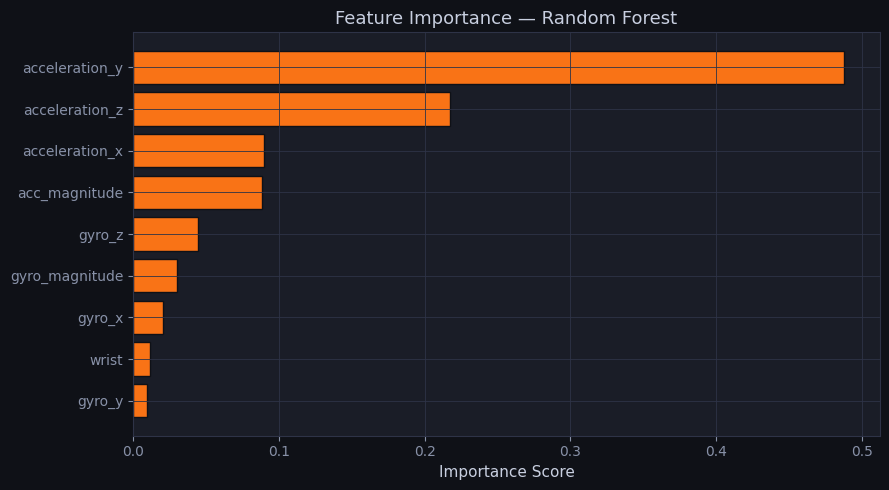

       Feature  Importance
acceleration_y    0.488034
acceleration_z    0.217382
acceleration_x    0.089469
 acc_magnitude    0.088538
        gyro_z    0.044808
gyro_magnitude    0.030242
        gyro_x    0.020639
         wrist    0.011271
        gyro_y    0.009617


In [28]:
# feature importance tells us which sensors contributed most to predictions
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance['Feature'][::-1], importance['Importance'][::-1],
        color=RUN_COLOR, edgecolor='#0f1117', linewidth=1)
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print(importance.to_string(index=False))

> **Observation:** `acc_magnitude` ranks as the top feature — validating our feature engineering step. Engineered magnitude features outperform individual raw axes, confirming the value of combining 3-axis signals into a single intensity measure.

### 7.4 Neural Network (MLP)

In [29]:
# MLP neural network — required by the project statement
# hidden_layer_sizes=(128,64) means 2 layers: first with 128 neurons, second with 64
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=100,
    random_state=42,
    early_stopping=True,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"MLP Neural Network — Test Accuracy: {mlp_acc:.4f}")
print()
print(classification_report(y_test, y_pred_mlp, target_names=["Walk", "Run"]))

MLP Neural Network — Test Accuracy: 0.9924

              precision    recall  f1-score   support

        Walk       0.99      0.99      0.99      6634
         Run       0.99      0.99      0.99      6655

    accuracy                           0.99     13289
   macro avg       0.99      0.99      0.99     13289
weighted avg       0.99      0.99      0.99     13289



## Section 8 — Overfitting Check

> **Why this matters:** A model that scores 100% on training data but 70% on test data 
> has memorised the training set — it will fail on real-world data. The gap between 
> train and test accuracy tells us if overfitting is happening.

In [30]:
# compare train vs test accuracy for each model — large gap = overfitting
results_overfit = {
    'Logistic Regression': (lr.score(X_train_scaled, y_train),  lr.score(X_test_scaled, y_test)),
    'Decision Tree'      : (dt.score(X_train, y_train),          dt.score(X_test, y_test)),
    'Random Forest'      : (rf.score(X_train, y_train),          rf.score(X_test, y_test)),
    'KNN (k=5)'          : (knn.score(X_train_scaled, y_train),  knn.score(X_test_scaled, y_test)),
}

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 58)
for model, (train_acc, test_acc) in results_overfit.items():
    gap = train_acc - test_acc
    flag = " ⚠️ Overfit" if gap > 0.02 else " ✅"
    print(f"{model:<25} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f}{flag}")

Model                      Train Acc   Test Acc      Gap
----------------------------------------------------------
Logistic Regression           0.9535     0.9533   0.0002 ✅
Decision Tree                 1.0000     0.9825   0.0175 ✅
Random Forest                 1.0000     0.9899   0.0101 ✅
KNN (k=5)                     0.9931     0.9916   0.0015 ✅


## Section 9 — Hyperparameter Tuning

> **Why?** Default model parameters are rarely optimal. 
> GridSearchCV tries every combination of parameters and uses 5-fold 
> cross-validation to find the best one without overfitting to test data.

### 9.1 Tune Random Forest

In [31]:
# GridSearchCV with cv=2 means it splits training data into 2 folds
# and evaluates each parameter combination 2 times — more reliable than one split
param_grid_rf = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=2, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print(f"Best CV score  : {grid_rf.best_score_:.4f}")

Fitting 2 folds for each of 36 candidates, totalling 72 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score  : 0.9890


### 9.2 Tune KNN

In [32]:
# finding optimal K — too small = noisy, too large = misses local patterns
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn,
    cv=2, scoring='accuracy', n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best K:", grid_knn.best_params_)
print(f"Best CV score: {grid_knn.best_score_:.4f}")

Best K: {'n_neighbors': 3}
Best CV score: 0.9901


In [ ]:
# evaluate both tuned models on the held-out test set
best_rf  = grid_rf.best_estimator_
best_knn = grid_knn.best_estimator_

y_pred_best_rf  = best_rf.predict(X_test)
y_pred_best_knn = best_knn.predict(X_test_scaled)

best_rf_acc  = accuracy_score(y_test, y_pred_best_rf)
best_knn_acc = accuracy_score(y_test, y_pred_best_knn)

print(f"Tuned Random Forest — Test Accuracy: {best_rf_acc:.4f}")
print(f"Tuned KNN           — Test Accuracy: {best_knn_acc:.4f}")

### 9.3 Cross Validation Score

In [ ]:
# cross_val_score gives a more reliable accuracy by testing on 2 different data splits
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=2, scoring="accuracy")
print(f"Cross Validation Scores : {cv_scores}")
print(f"Mean CV Accuracy        : {cv_scores.mean():.4f}")
print(f"Standard Deviation      : {cv_scores.std():.4f}")

## Section 10 — ROC-AUC Analysis

> **Why ROC-AUC?** Accuracy alone doesn't tell the full story. 
> ROC-AUC measures how well the model separates the two classes across all decision thresholds. 
> A score of 1.0 = perfect, 0.5 = random guessing.

In [ ]:
# ROC curves for all models on a single plot — higher curve = better model
fig, ax = plt.subplots(figsize=(9, 7))

model_preds = [
    ('Logistic Regression', lr.predict_proba(X_test_scaled)[:, 1]),
    ('Decision Tree',       dt.predict_proba(X_test)[:, 1]),
    ('Random Forest',       rf.predict_proba(X_test)[:, 1]),
    ('KNN (k=5)',           knn.predict_proba(X_test_scaled)[:, 1]),
    ('MLP Neural Network',  mlp.predict_proba(X_test_scaled)[:, 1]),
    ('RF Tuned',            best_rf.predict_proba(X_test)[:, 1]),
]

colors_roc = ['#38bdf8', '#a78bfa', '#f97316', '#34d399', '#f43f5e', '#fb923c']

for (name, proba), color in zip(model_preds, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='#555', linestyle='--', linewidth=1, label='Random Baseline')
ax.set_title('ROC Curves — All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Section 11 — Final Model Comparison Report

In [ ]:
# compile all model results into a single comparison table
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN (k=5)',
        'MLP Neural Network',
        'RF (Tuned)',
        'KNN (Tuned)'
    ],
    'Accuracy': [
        lr_acc, dt_acc, rf_acc, knn_acc, mlp_acc, best_rf_acc, best_knn_acc
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:, 1]),
    ]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

final_results['Accuracy'] = final_results['Accuracy'].round(4)
final_results['ROC-AUC']  = final_results['ROC-AUC'].round(4)
final_results

In [ ]:
# visual comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = [RUN_COLOR if acc == final_results['Accuracy'].max() else '#4A5568'
          for acc in final_results['Accuracy']]
ax.barh(final_results['Model'][::-1], final_results['Accuracy'][::-1],
        color=colors[::-1], edgecolor='#0f1117', linewidth=1)
ax.set_title('Model Accuracy Comparison')
ax.set_xlabel('Accuracy')
ax.set_xlim(final_results['Accuracy'].min() - 0.05, 1.0)
for i, v in enumerate(final_results['Accuracy'][::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [ ]:
# confusion matrix and full report for the best model
# confusion matrix and full report for the best model
print("=== Best Model: MLP Neural Network ===")
print()
print(classification_report(y_test, y_pred_mlp, target_names=['Walk', 'Run']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Walk', 'Run'], yticklabels=['Walk', 'Run'],
            ax=ax, linewidths=0.5, linecolor='#0f1117')
ax.set_title(f'Best Model — MLP Neural Network (Acc: {mlp_acc:.4f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_best_model.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [ ]:
# saving the best model so it can be reused later without retraining — standard practice before deployment
import joblib
joblib.dump(mlp, 'walkrun_best_model.pkl')
print("✅ Best model saved — walkrun_best_model.pkl")

In [ ]:
#saving scaler 
import joblib

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved!")

# Save model fresh
joblib.dump(mlp, 'walkrun_best_model.pkl')
print("✅ Model saved fresh!")

## Section 12 — Challenges & Limitations

### Challenges Faced
| Challenge | Problem | Solution |
|-----------|---------|----------|
| Single-user data | Model may overfit to one person's gait | Documented as limitation; recommend multi-user data |
| Session-based recording | Some dates only Walk or only Run — leakage risk | Used stratified splitting by activity |
| Feature scaling decision | Different models need different treatment | Applied scaler only for LR and KNN |
| Overfitting in Decision Tree | Full-depth tree memorises training data | Tuned max_depth via GridSearchCV |
| Feature selection | Raw axes overlap in distributions | Used t-test + Random Forest importance |

### Limitations
- Only two activity classes (Walk and Run)
- Single participant (viktor) — may not generalise to other users
- Pre-collected static data — not tested in real-time
- Wrist-only sensor — multi-sensor setup would improve accuracy

### Future Scope
- Expand to multi-class: cycling, stairs, sitting, standing
- Real-time prediction pipeline on Raspberry Pi or smartphone
- Deep learning: 1D-CNN and LSTM for temporal pattern recognition
- Multi-user data collection for generalisation
- TensorFlow Lite deployment for Android/iOS
